In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as pltimg
import cv2
from PIL import Image

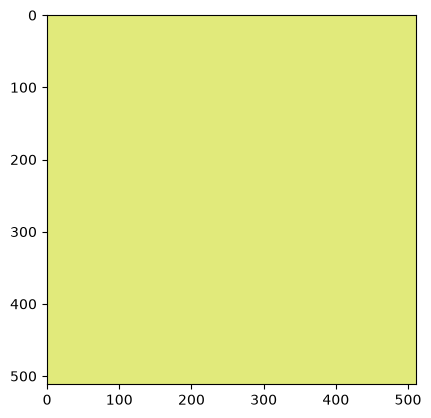

In [10]:
img = np.zeros((512,512,3),np.uint8)
img[:] = [225,234,123]
plt.imshow(img)

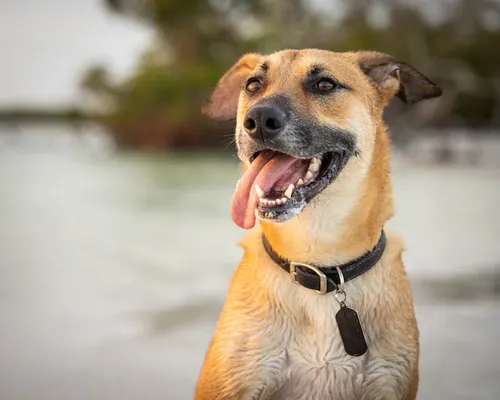

In [16]:
Image.open('/home/gaming/projects/cvdev-project/img2.webp')

# Converting Image Into Array


In [38]:
img = np.asarray(Image.open('/home/gaming/projects/cvdev-project/img2.webp'))

In [17]:
print(img)

[[[195 191 190]
  [195 191 190]
  [195 191 190]
  ...
  [112 111 105]
  [116 114 108]
  [118 117 110]]

 [[195 191 190]
  [195 191 190]
  [195 191 190]
  ...
  [108 106 100]
  [111 110 103]
  [113 112 106]]

 [[195 191 190]
  [195 191 190]
  [195 191 190]
  ...
  [101  99  93]
  [104 103  96]
  [106 105  99]]

 ...

 [[154 146 140]
  [155 147 141]
  [155 147 141]
  ...
  [138 141 138]
  [137 140 137]
  [137 140 137]]

 [[154 146 140]
  [155 147 141]
  [155 147 141]
  ...
  [138 141 138]
  [137 140 137]
  [137 140 137]]

 [[154 146 140]
  [155 147 141]
  [155 147 141]
  ...
  [138 141 138]
  [137 140 137]
  [137 140 137]]]


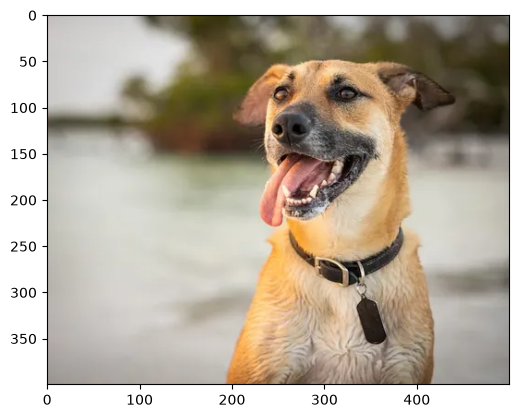

In [37]:
# Ploting the array into image 
plt.imshow(img)


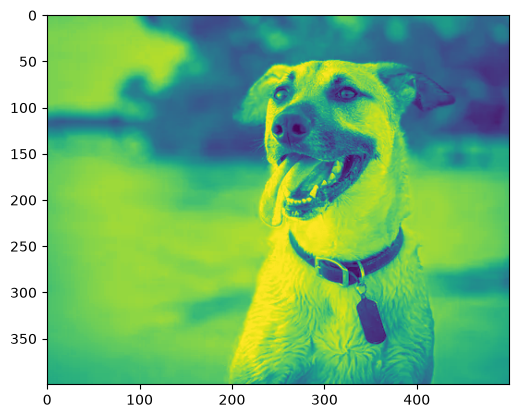

In [19]:
plt.imshow(img[:,:,0])

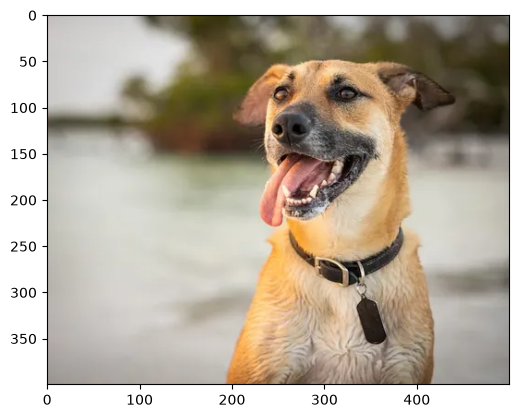

In [21]:
plt.imshow(img,cmap="hot")

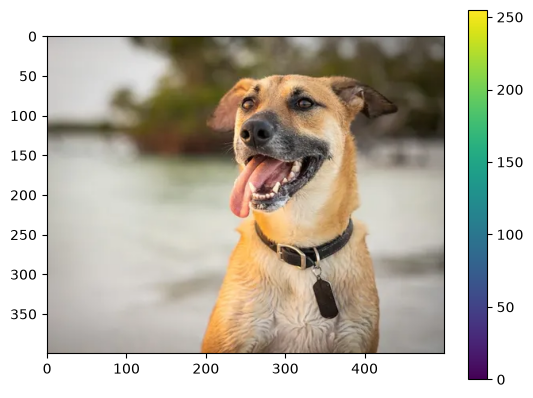

In [22]:
plt.imshow(img)
plt.colorbar()

In [5]:
B,G ,R = cv2.split(img)

In [6]:
Z= np.zeros(B.shape,dtype=B.dtype)

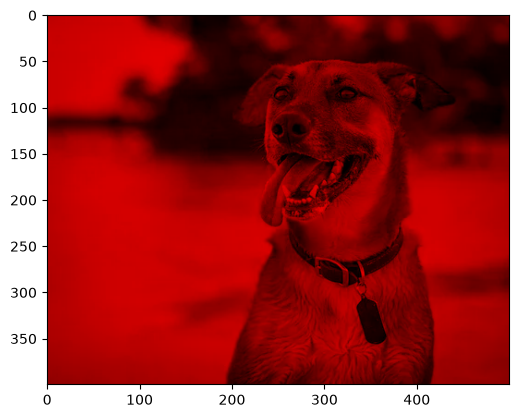

In [8]:
plt.imshow(cv2.merge((R,Z,Z)))

In [9]:
sobel = np.array([
    [1,0,-1],
    [2,0,-2],
    [1,0,-1]
])

In [19]:
image = np.array([
    [ 10,  10,  10,  10, 200, 200, 200, 200],
    [ 10,  10,  10,  10, 200, 200, 200, 200],
    [ 10,  10,  10,  10, 200, 200, 200, 200],
    [ 10,  10,  10,  10, 200, 200, 200, 200],
    [ 0,  10,  0,  0, 00, 00, 200, 200],
    [ 10,  10,  10,  10, 200, 200, 200, 200],
    [ 10,  10,  10,  10, 200, 200, 200, 200],
    [ 0,  0,  0,  10, 200, 200, 200, 200],
], dtype=np.float32)

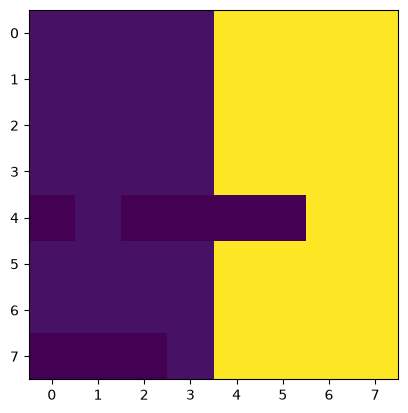

In [20]:
plt.imshow(image)

# Lets put filter to Identify the vertical line 

In [22]:
def vertical_strip(imagee , kernel):
    img_h, img_w= imagee.shape

    k_h,k_w = kernel.shape

    # Padding size 
    pad_h, pad_w = k_h//2 , k_w//2

    #padding the image with zeros around the boundaries

    padded = np.pad(imagee,((pad_h,pad_h),(pad_w,pad_w)),mode='constant',constant_values=0)

    # Output image of same size 
    output = np.zeros_like(imagee,dtype=np.float32)

    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+k_h,j:j+k_w]

            output[i,j] = np.sum(region * kernel)

    return output


In [23]:
vertical_img=vertical_strip(image,sobel)

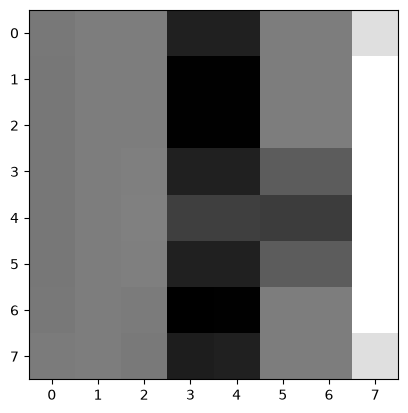

In [26]:
plt.imshow(vertical_img,cmap='gray')

In [50]:
dog_grey =cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)

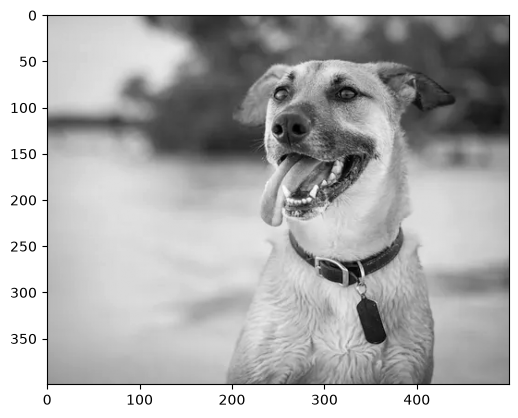

In [52]:
plt.imshow(dog_grey,cmap='gray')

In [53]:
dog_outline= vertical_strip(dog_grey,sobel)

# Vertical Feature Extraction


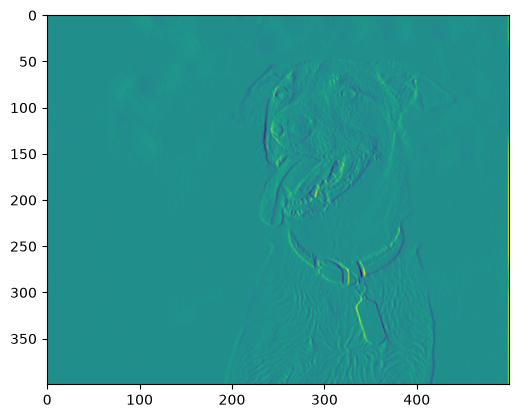

In [54]:
plt.imshow(dog_outline)

# Horizontal Filter

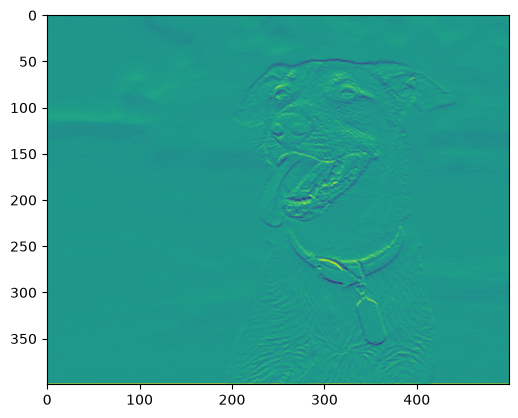

In [55]:
plt.imshow(vertical_strip(dog_grey,sobel.T))